In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import GridSearchCV


Rows Columns
(400, 3)
   Age  EstimatedSalary  class
0   19            19000      0
1   35            20000      0
2   26            43000      0
3   27            57000      0
4   19            76000      0

 class
0    257
1    143
Name: count, dtype: int64


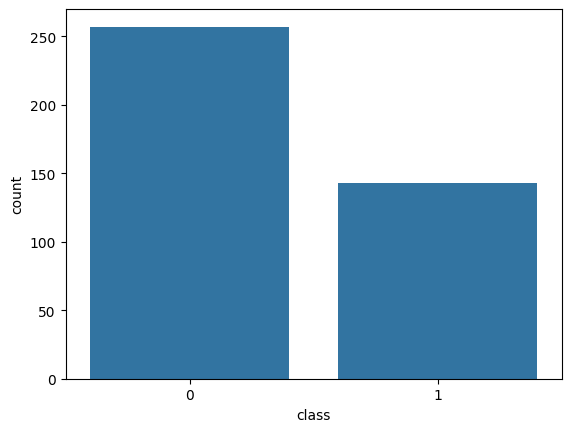

<Figure size 640x480 with 0 Axes>

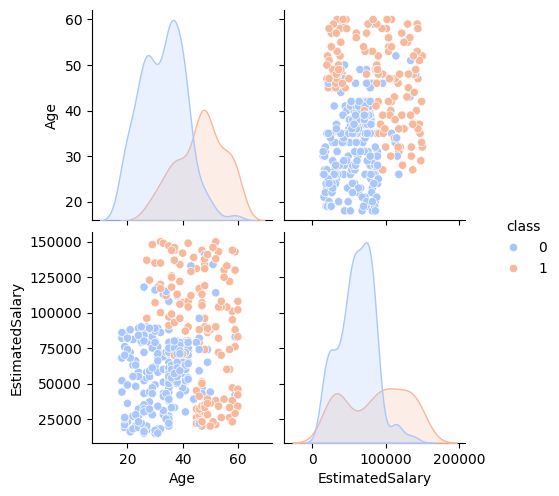

<Figure size 640x480 with 0 Axes>

In [ ]:
#Read and Display Data Set

#First, read in CSV and assign it to a variable called "data"
data = pd.read_csv("data/kyphosis.csv")

#Second, display maximum rows and columns
print('\nRows Columns') #Indicates rows and columns
print(data.shape) #gets the number of rows and columns of data set

pd.set_option('display.max_columns', None) #optional setting to show all feature columns

#Third, display first five rows to check data
print(data.head(5))

#Select last column (assuming the last column is the class)
last_column = data.iloc[:, -1] #using iloc to select the last column

#Count occurences of 0's and 1's
value_counts = last_column.value_counts()

#Print the value counts and check for imbalance
print('\n' , value_counts)
#----------EXTRA INFO ------------
sns.countplot(x="class", data=data)
plt.show()
plt.clf()

sns.pairplot(data,hue='class', palette='coolwarm')
plt.show()
plt.clf()

Axes(0.125,0.11;0.62x0.77)


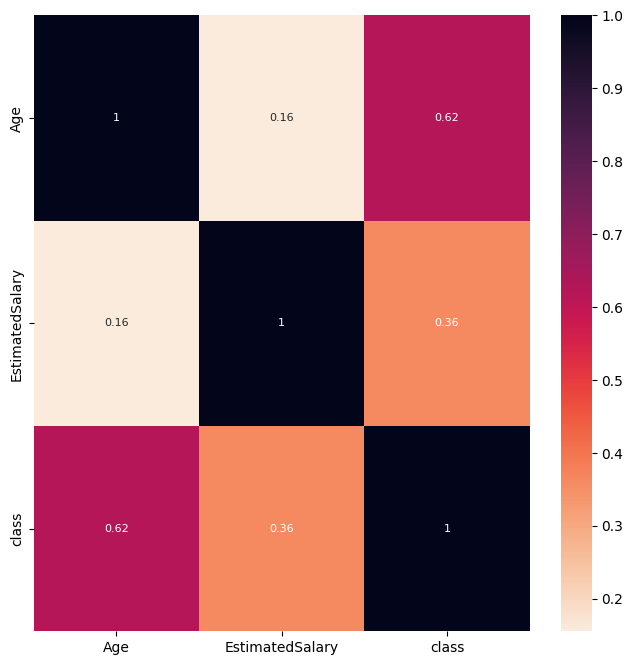

In [ ]:
#Display Feature Relations of Data Set
plt.figure(figsize=(8,8)) #Adjust width and height
print(sns.heatmap(data.corr(),annot=True, annot_kws={"size":8}, cmap= sns.cm.rocket_r))

In [ ]:
#Standardise Data to Same Scale
#The scaler tool learns the mean and standard deviation of each data column to undestand its distribution
#The scaler transfrom() function trasforms the data so that they all have a similar range
scaler = StandardScaler()
scaler.fit(data.drop('class', axis=1))#incluse all features except last column
scaled_features = scaler.transform(data.drop('class', axis=1)) #transform data
data_feat = pd.DataFrame(scaled_features, columns=data.columns[:-1])
data_feat.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [ ]:
#Declare X and Y Variables and Split the Dataset into Train and Test sections
X=data.drop(['class'], axis=1).values #X Variables = all common except the last one

#Declare last column to be the Dependent variable Y
y=data['class'].values #Y Variable = last column

#Split Data Set 70% training and 30% Testing. Initial data shuffle to zero
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7,test_size=0.3, random_state=0)

In [ ]:
#Create and Test the Model

#First, declare a new model
classifier_model = KNeighborsClassifier()

#Second, Train (fit) the model from the training data
classifier_model.fit(X_train, y_train)

#Fourth, Test the model using the testing data
y_pred = classifier_model.predict(X_test)
print('\nTest Data Model = ', y_pred)


Test Data Model =  [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1
 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 0 0 1
 0 0 0 1 0 1 0 0 0]


In [ ]:
#Evaluate Model
print('\nConfusion Matrix = \n', confusion_matrix(y_test, y_pred))
print('\nAccuracy = ', accuracy_score(y_test, y_pred))
print('\nPrecision = ', precision_score(y_test, y_pred))
print('\nRecall = ', recall_score(y_test, y_pred))
print('\nF1 Score = ', f1_score(y_test, y_pred))


Confusion Matrix = 
 [[69 10]
 [11 30]]

Accuracy =  0.825

Precision =  0.75

Recall =  0.7317073170731707

F1 Score =  0.7407407407407407


In [ ]:
#Optimising the Model for better metrics

param_grid = {
    'n_neighbors':[2, 5, 10, 20, 30]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, verbose=3)
grid.fit(X_train, y_train)
grid.best_params_
grid_predictions = grid.predict(X_test)
print('\nConfusion Matrix = \n', confusion_matrix(y_test, grid_predictions))

#Display the performance metrics
print("\nEvaluation Metrics")
print('\nConfusion Matrix = \n', confusion_matrix(y_test, y_pred))
print('\nAccuracy = ', accuracy_score(y_test, y_pred))
print('\nPrecision = ', precision_score(y_test, y_pred))
print('\nRecall = ', recall_score(y_test, y_pred))
print('\nF1 Score = ', f1_score(y_test, y_pred))

#Display best parameters
print("\nBest Parameters")
print=(grid.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV 1/3] END .....................n_neighbors=2;, score=0.777 total time=   0.0s
[CV 2/3] END .....................n_neighbors=2;, score=0.710 total time=   0.0s
[CV 3/3] END .....................n_neighbors=2;, score=0.753 total time=   0.0s
[CV 1/3] END .....................n_neighbors=5;, score=0.809 total time=   0.0s
[CV 2/3] END .....................n_neighbors=5;, score=0.785 total time=   0.0s
[CV 3/3] END .....................n_neighbors=5;, score=0.785 total time=   0.0s
[CV 1/3] END ....................n_neighbors=10;, score=0.798 total time=   0.0s
[CV 2/3] END ....................n_neighbors=10;, score=0.753 total time=   0.0s
[CV 3/3] END ....................n_neighbors=10;, score=0.806 total time=   0.0s
[CV 1/3] END ....................n_neighbors=20;, score=0.830 total time=   0.0s
[CV 2/3] END ....................n_neighbors=20;, score=0.742 total time=   0.0s
[CV 3/3] END ....................n_neighbors=20;,

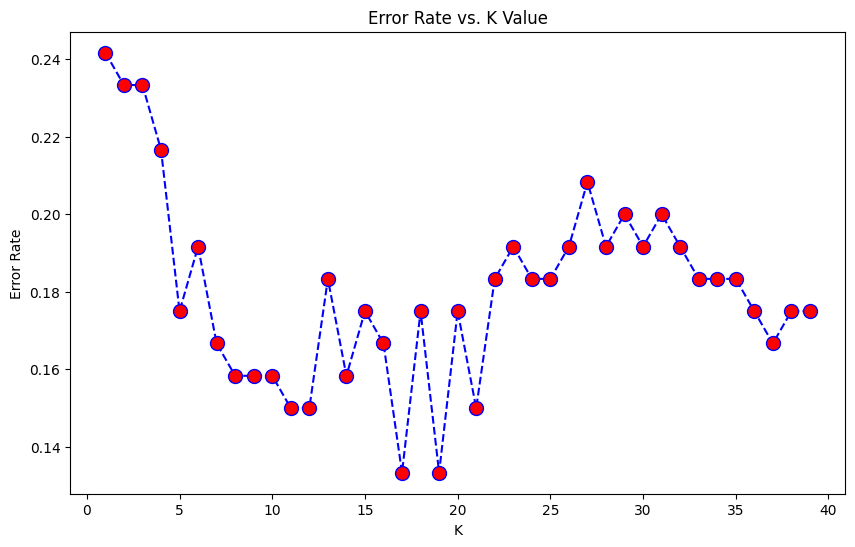

In [ ]:
#Estimate optimal value of k using the Elbow method
error_rate = []

for i in range (1,40):
  classifier_model = KNeighborsClassifier(n_neighbors=i)
  classifier_model.fit(X_train, y_train)
  pred_i = classifier_model.predict(X_test)
  error_rate.append(np.mean(pred_i != y_test))

#Plot results
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()